# 2. Стационарность и автокорреляция

Это центральная часть теории временных рядов.

Здесь мы разберём:

1. Что такое стационарность
2. Слабая (ковариационная) стационарность
3. Автоковариация и автокорреляция
4. ACF и PACF
5. Интуицию на примерах белого шума, AR и случайного блуждания

Это фундамент для ARIMA и всех дальнейших моделей.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## 1. Интуитивная идея

Стационарный ряд — это ряд, чьи статистические свойства
не меняются со временем.

Если мы "сдвинем" ряд на 10 периодов,
его поведение будет таким же.

Если свойства меняются (например, растёт среднее),
ряд нестационарный.

## 2. Слабая (ковариационная) стационарность

Ряд $Y_t$ называется слабостационарным, если:

1) $$ E(Y_t) = \mu = const $$

2) $$ Var(Y_t) = \sigma^2 = const $$

3) $$ Cov(Y_t, Y_{t-k}) = \gamma_k $$

и ковариация зависит только от лага $k$, а не от времени $t$.

Это ключевое определение.

## Белый шум

$$
Y_t = \varepsilon_t, \quad \varepsilon_t \sim iid(0, \sigma^2)
$$

Свойства:
- среднее = 0
- дисперсия постоянна
- автокорреляция равна 0 для всех лагов $k \neq 0$

Это идеальный стационарный процесс.

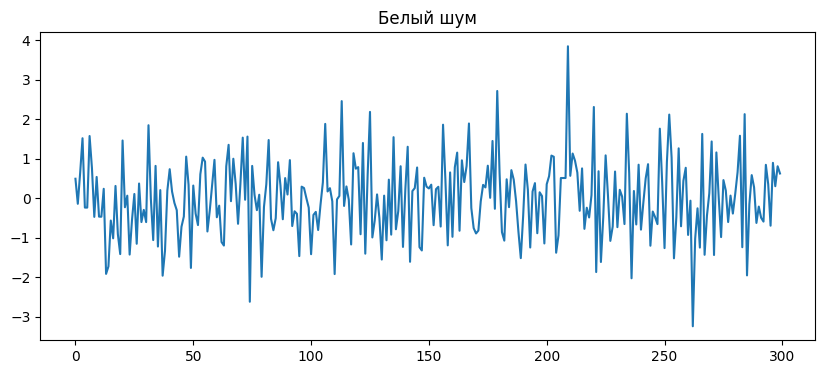

In [3]:
np.random.seed(42)
T = 300

white_noise = np.random.normal(0, 1, T)

plt.figure(figsize=(10,4))
plt.plot(white_noise)
plt.title("Белый шум")
plt.show()

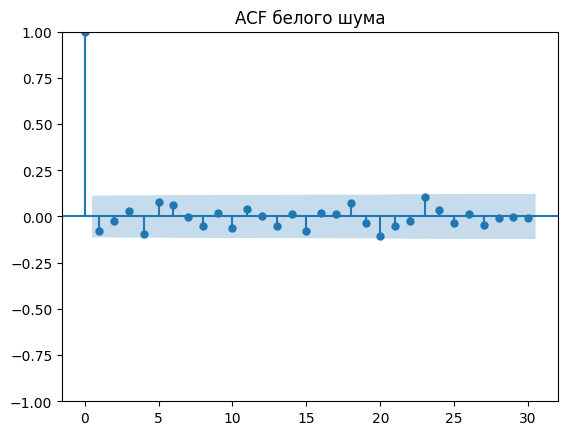

In [4]:
plot_acf(white_noise, lags=30)
plt.title("ACF белого шума")
plt.show()

Интуиция:

ACF ≈ 0 для всех лагов (кроме 0).

Это означает отсутствие памяти.

## Случайное блуждание

$$
Y_t = Y_{t-1} + \varepsilon_t
$$

Свойства:
- среднее меняется
- дисперсия растёт со временем
- сильная зависимость от прошлого

Это пример стохастического тренда.

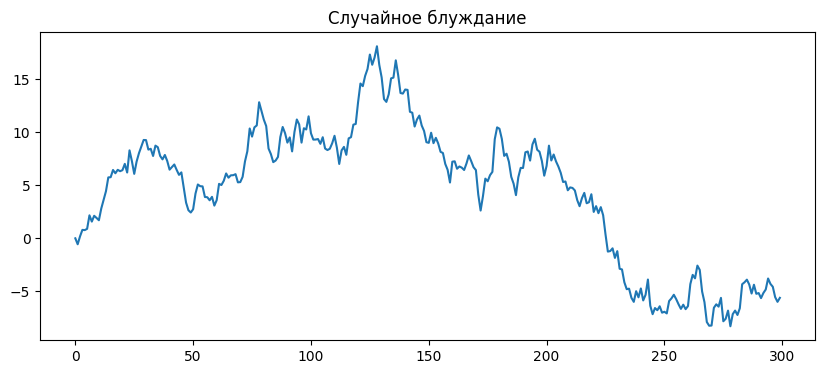

In [5]:
eps = np.random.normal(0, 1, T)
rw = np.zeros(T)

for t in range(1, T):
    rw[t] = rw[t-1] + eps[t]

plt.figure(figsize=(10,4))
plt.plot(rw)
plt.title("Случайное блуждание")
plt.show()

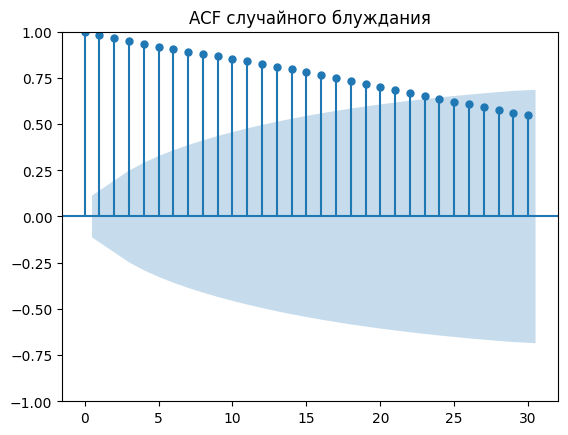

In [6]:
plot_acf(rw, lags=30)
plt.title("ACF случайного блуждания")
plt.show()

Интуиция:

ACF убывает очень медленно → высокая зависимость.

Это признак нестационарности.

## Автоковариация

$$
\gamma_k = Cov(Y_t, Y_{t-k})
$$

## Автокорреляция

$$
\rho_k = \frac{\gamma_k}{\gamma_0}
$$

где:
- $\gamma_0 = Var(Y_t)$

Автокорреляция показывает силу связи
между значениями через $k$ периодов.

## AR(1)

$$
Y_t = \phi Y_{t-1} + \varepsilon_t
$$

Если $|\phi| < 1$ — процесс стационарный.

Если $|\phi| \ge 1$ — нестационарный.

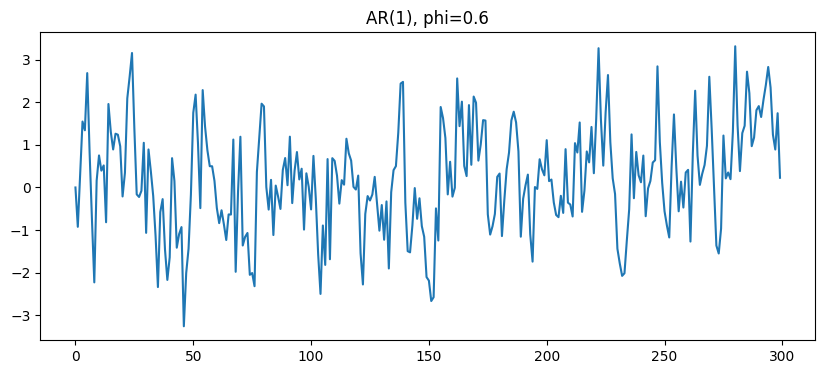

In [7]:
phi = 0.6
eps = np.random.normal(0, 1, T)
ar1 = np.zeros(T)

for t in range(1, T):
    ar1[t] = phi * ar1[t-1] + eps[t]

plt.figure(figsize=(10,4))
plt.plot(ar1)
plt.title("AR(1), phi=0.6")
plt.show()

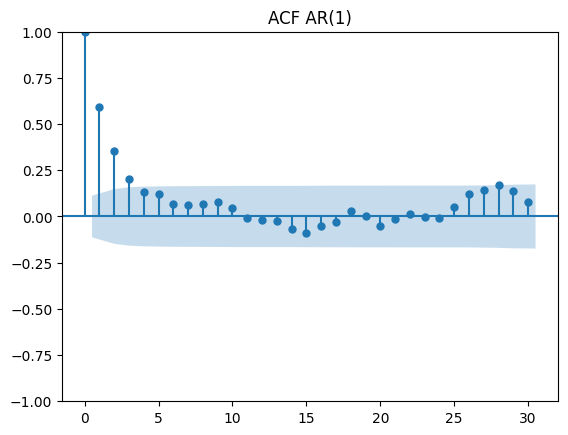

In [8]:
plot_acf(ar1, lags=30)
plt.title("ACF AR(1)")
plt.show()

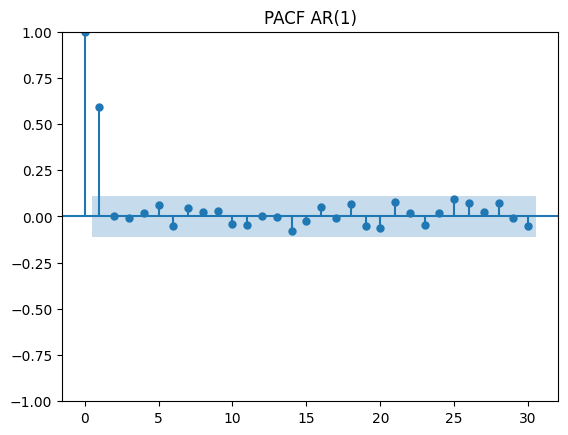

In [9]:
plot_pacf(ar1, lags=30)
plt.title("PACF AR(1)")
plt.show()

Интуиция:

- ACF постепенно убывает.
- PACF обрывается после 1 лага.

Это характерный признак AR(1).

## ADF-тест (Augmented Dickey-Fuller)

Проверяет гипотезу:

$$
H_0: \text{есть единичный корень (ряд нестационарный)}
$$

Если p-value < 0.05 → отвергаем $H_0$ → ряд стационарен.

In [10]:
def adf_test(series):
    result = adfuller(series)
    print("ADF statistic:", result[0])
    print("p-value:", result[1])

print("Белый шум")
adf_test(white_noise)

print("\nAR(1)")
adf_test(ar1)

print("\nRandom Walk")
adf_test(rw)

Белый шум
ADF statistic: -18.63158868745226
p-value: 2.0573777051814552e-30

AR(1)
ADF statistic: -8.700358474516484
p-value: 3.824039535166345e-14

Random Walk
ADF statistic: -0.9053134294747418
p-value: 0.7862175931796229


Ожидаемый результат:

- Белый шум → стационарен
- AR(1) при |phi|<1 → стационарен
- Random Walk → нестационарен

## Главное, что нужно понять

1. Стационарность — фундамент временных рядов.
2. Большинство моделей требуют стационарности.
3. ACF показывает зависимость по лагам.
4. PACF помогает определить порядок AR.
5. Random Walk — типичный пример нестационарности.
6. ADF-тест — способ формально проверить стационарность.

Дальше логично перейти к:

- AR(p)
- MA(q)
- ARMA
- ARIMA

# 3. AR, MA, ARMA и ARIMA модели

Теперь мы переходим к моделям, которые описывают
зависимость текущего значения от прошлого.

Это сердце классической теории временных рядов.

## 1. Авторегрессия (AR)

AR = AutoRegressive = "авторегрессионная модель"

Идея:

Текущее значение зависит от своих прошлых значений.

Простейший случай:

$$
Y_t = \phi Y_{t-1} + \varepsilon_t
$$

Это AR(1).

Где:
- $\phi$ — коэффициент памяти
- $\varepsilon_t$ — белый шум

Если $|\phi| < 1$ → процесс стационарный.

### Интуиция

Если $\phi = 0.8$:
- 80% прошлого значения "переносится" в настоящее.

Если $\phi = 0$:
- памяти нет → белый шум.

Если $\phi = 1$:
- получаем случайное блуждание.

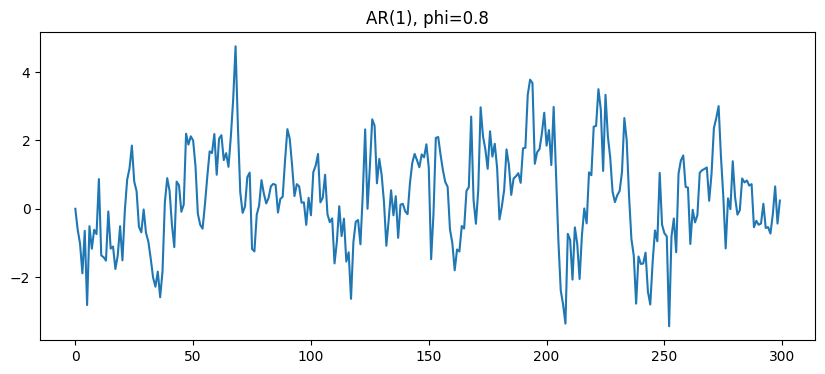

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

np.random.seed(1)
T = 300
phi = 0.8

eps = np.random.normal(0,1,T)
ar1 = np.zeros(T)

for t in range(1,T):
    ar1[t] = phi * ar1[t-1] + eps[t]

plt.figure(figsize=(10,4))
plt.plot(ar1)
plt.title("AR(1), phi=0.8")
plt.show()

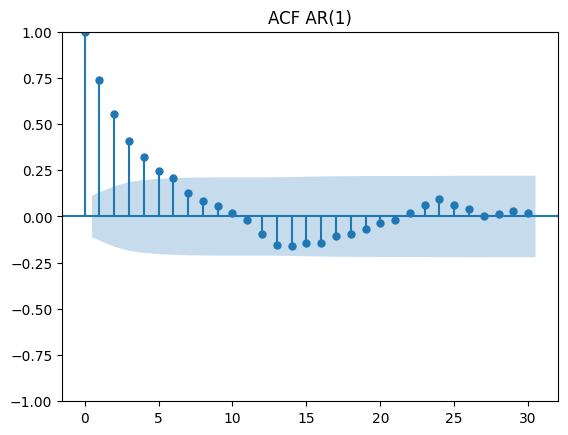

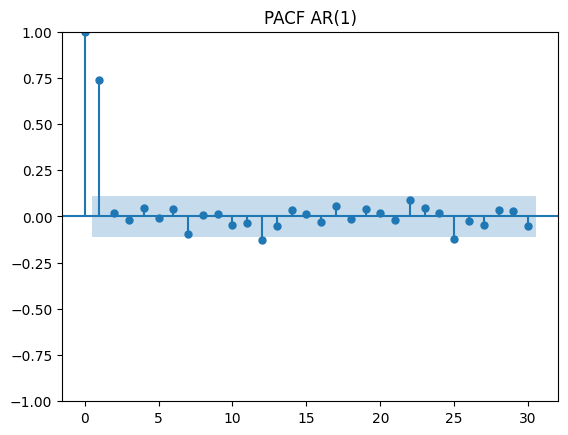

In [12]:
plot_acf(ar1, lags=30)
plt.title("ACF AR(1)")
plt.show()

plot_pacf(ar1, lags=30)
plt.title("PACF AR(1)")
plt.show()

### Паттерн:

- ACF постепенно убывает
- PACF резко обрывается после лага 1

Это характерный "отпечаток" AR(1).

## 2. Скользящее среднее (MA)

MA = Moving Average

Важно: это не та скользящая средняя,
которую мы использовали для сглаживания.

Здесь модель строится так:

$$
Y_t = \varepsilon_t + \theta \varepsilon_{t-1}
$$

Это MA(1).

Текущее значение зависит от:
- текущего шока
- прошлого шока

### Интуиция

AR — зависимость от прошлых значений Y.

MA — зависимость от прошлых ошибок.

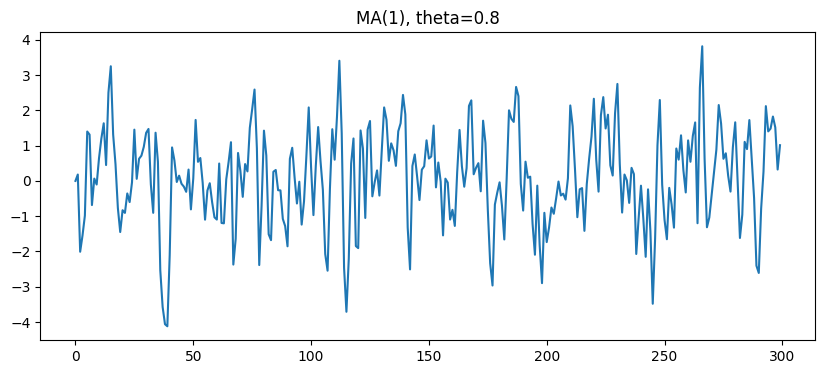

In [13]:
theta = 0.8
eps = np.random.normal(0,1,T)
ma1 = np.zeros(T)

for t in range(1,T):
    ma1[t] = eps[t] + theta * eps[t-1]

plt.figure(figsize=(10,4))
plt.plot(ma1)
plt.title("MA(1), theta=0.8")
plt.show()

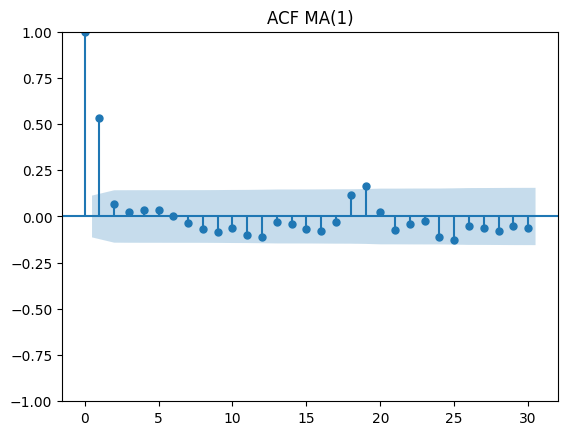

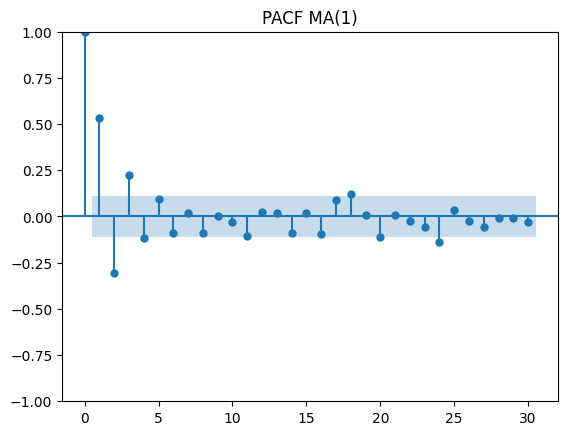

In [14]:
plot_acf(ma1, lags=30)
plt.title("ACF MA(1)")
plt.show()

plot_pacf(ma1, lags=30)
plt.title("PACF MA(1)")
plt.show()

### Паттерн:

- ACF обрывается после лага 1
- PACF постепенно затухает

Это зеркальная ситуация относительно AR.

## 3. ARMA(p,q)

ARMA = AutoRegressive Moving Average

Общая модель:

$$
Y_t = \phi_1 Y_{t-1} + ... + \phi_p Y_{t-p}
+ \varepsilon_t
+ \theta_1 \varepsilon_{t-1} + ... + \theta_q \varepsilon_{t-q}
$$

Она объединяет:
- зависимость от прошлых значений
- зависимость от прошлых ошибок

Важно: ARMA применяется только к стационарным рядам.

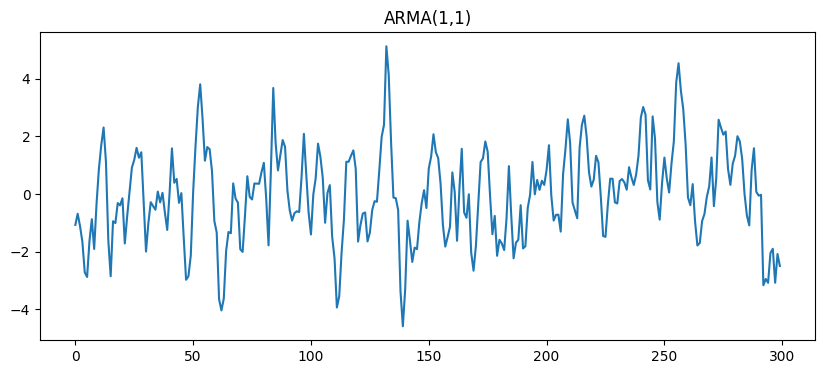

In [15]:
from statsmodels.tsa.arima_process import ArmaProcess

ar = np.array([1, -0.6])
ma = np.array([1, 0.5])

arma_process = ArmaProcess(ar, ma)
arma_sample = arma_process.generate_sample(nsample=300)

plt.figure(figsize=(10,4))
plt.plot(arma_sample)
plt.title("ARMA(1,1)")
plt.show()

## Единичный корень

Рассмотрим AR(1):

$$
Y_t = \phi Y_{t-1} + \varepsilon_t
$$

Если $\phi = 1$, получаем:

$$
Y_t = Y_{t-1} + \varepsilon_t
$$

Это случайное блуждание.

Говорят, что процесс имеет "единичный корень",
если характеристическое уравнение имеет корень 1.

Интуитивно:

Единичный корень = шоки не затухают.
Процесс не возвращается к среднему.

Это и есть нестационарность.

## ARIMA(p,d,q)

ARIMA = AutoRegressive Integrated Moving Average

Идея:

Если ряд нестационарен,
мы берём разности:

$$
\Delta Y_t = Y_t - Y_{t-1}
$$

Если после $d$ разностей ряд становится стационарным,
строим ARMA на разностях.

Это и есть ARIMA(p,d,q).

### Пример

Random Walk:

$$
Y_t = Y_{t-1} + \varepsilon_t
$$

Берём разность:

$$
\Delta Y_t = \varepsilon_t
$$

Получаем белый шум.

Значит Random Walk — это ARIMA(0,1,0).

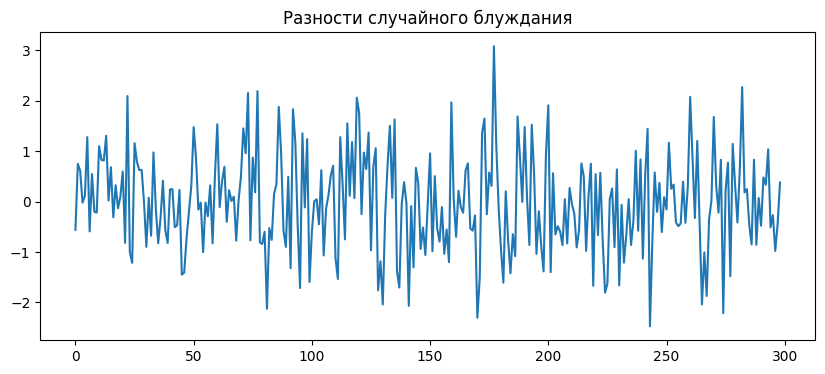

In [16]:
diff_rw = np.diff(rw)

plt.figure(figsize=(10,4))
plt.plot(diff_rw)
plt.title("Разности случайного блуждания")
plt.show()

## Что важно понять

1. AR — зависимость от прошлых значений.
2. MA — зависимость от прошлых ошибок.
3. ARMA — комбинация.
4. Если есть единичный корень → ряд нестационарен.
5. ARIMA — модель для нестационарных рядов через разности.

Теперь у нас есть:

- понимание стационарности
- понимание ACF и PACF
- понимание AR, MA, ARMA, ARIMA

Это фундамент всей классической теории временных рядов.

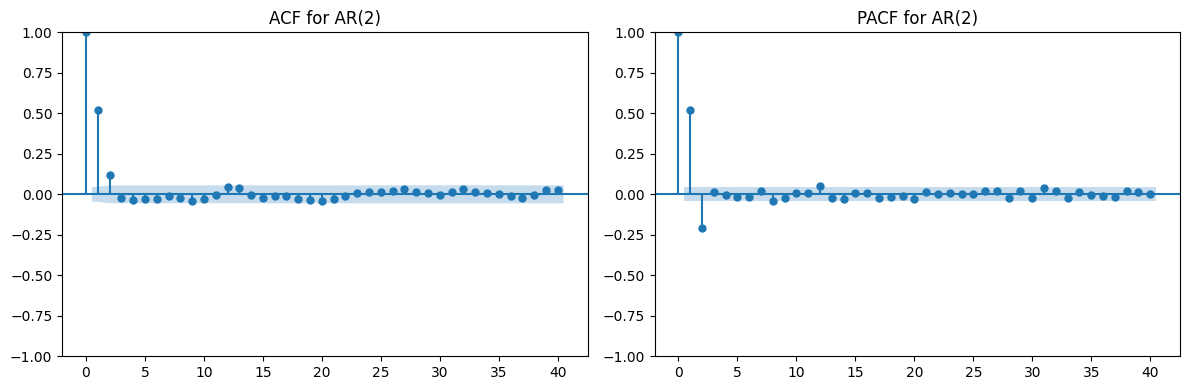

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess

phi1, phi2 = 0.6, -0.2
n = 2000
burn_in = 200
lags = 40

ar = np.array([1.0, -phi1, -phi2])
ma = np.array([1.0])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=n, burnin=burn_in, scale=1.0, distrvs=np.random.default_rng(42).normal)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(y, lags=lags, ax=ax[0])
ax[0].set_title("ACF for AR(2)")

plot_pacf(y, lags=lags, ax=ax[1], method="ywm")
ax[1].set_title("PACF for AR(2)")

plt.tight_layout()
plt.show()